In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in Jupyter Notebook
%matplotlib inline

# Set plot style
sns.set(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv(r"C:\Users\GRISHA V\OneDrive\Pictures\ds\titanic\train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
missing = df.isnull().sum()

missing_percent = (missing/len(df))*100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

missing_df

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


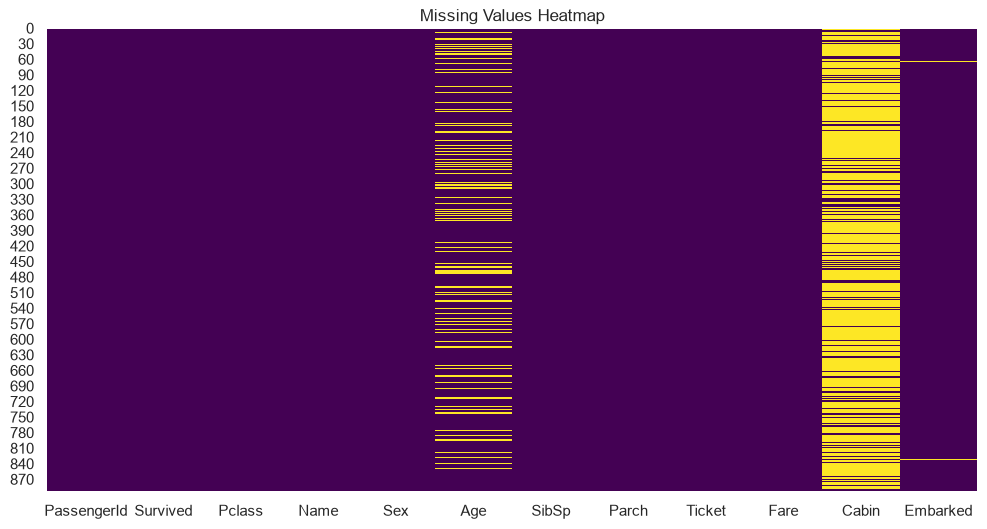

In [10]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

In [11]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [14]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [15]:
df = df.drop(columns="Cabin")

In [16]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [17]:
survival_rate = df["Survived"].mean()*100

print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


In [18]:
survival_gender = df.groupby("Sex")["Survived"].mean()

survival_gender

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

C:\Users\GRISHA V\AppData\Local\Temp\ipykernel_4444\794166554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,


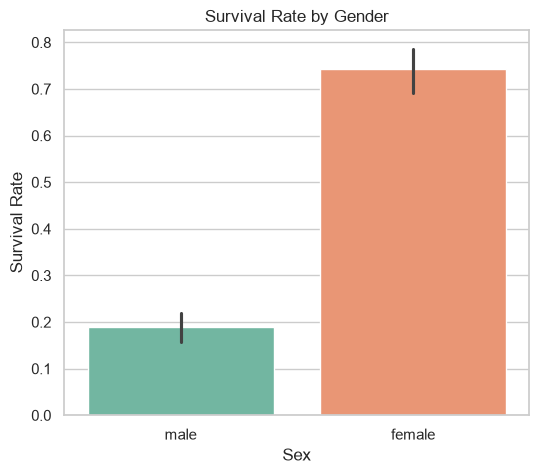

In [19]:
plt.figure(figsize=(6,5))

sns.barplot(data=df,
            x="Sex",
            y="Survived",
            palette="Set2")

plt.title("Survival Rate by Gender")

plt.ylabel("Survival Rate")

plt.show()

In [20]:
survival_class = df.groupby("Pclass")["Survived"].mean()

survival_class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

C:\Users\GRISHA V\AppData\Local\Temp\ipykernel_4444\602180122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,


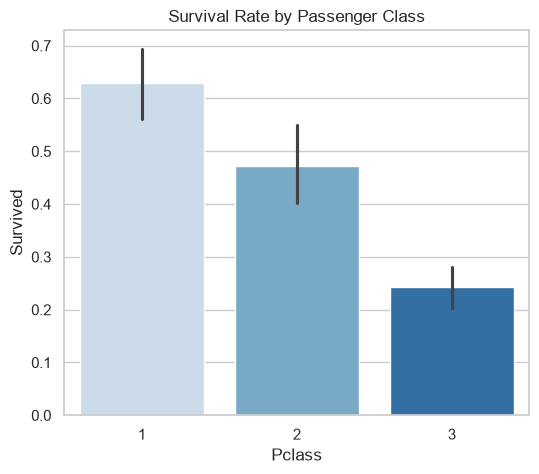

In [22]:
plt.figure(figsize=(6,5))

sns.barplot(data=df,
            x="Pclass",
            y="Survived",
            palette="Blues")

plt.title("Survival Rate by Passenger Class")

plt.show()

In [24]:
bins = [0,12,18,35,60,100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["Age_Group"] = pd.cut(df["Age"],
                         bins=bins,
                         labels=labels)

In [25]:
df[["Age","Age_Group"]].head()

,Age,Age_Group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult


In [26]:
age_survival = df.groupby("Age_Group")["Survived"].mean()

age_survival

Age_Group
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64

C:\Users\GRISHA V\AppData\Local\Temp\ipykernel_4444\18060146.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,


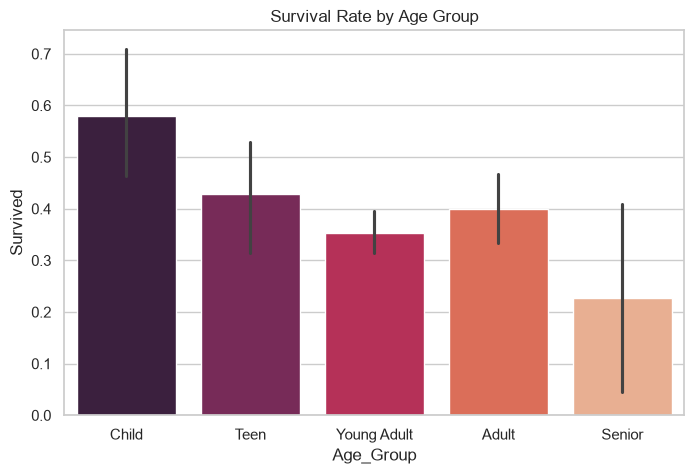

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(data=df,
            x="Age_Group",
            y="Survived",
            palette="rocket")

plt.title("Survival Rate by Age Group")

plt.show()

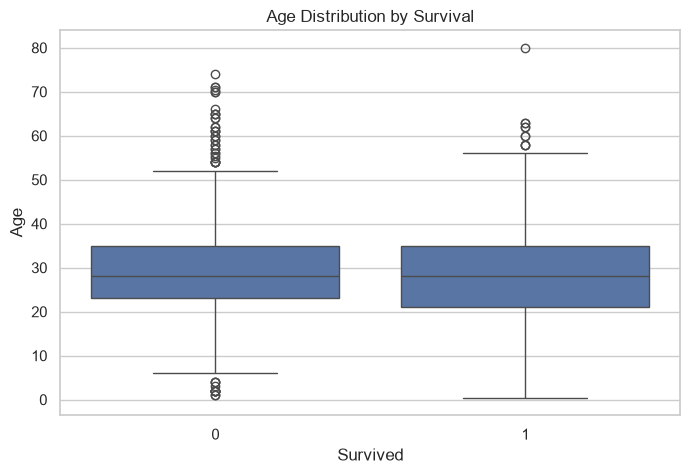

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Survived",
            y="Age")

plt.title("Age Distribution by Survival")

plt.show()

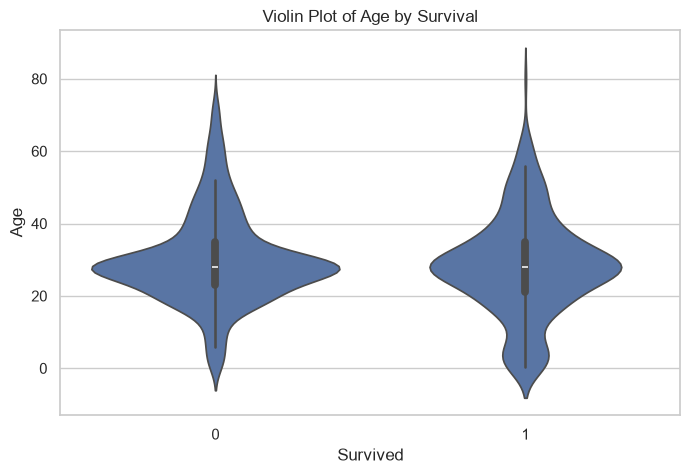

In [29]:
plt.figure(figsize=(8,5))

sns.violinplot(data=df,
               x="Survived",
               y="Age")

plt.title("Violin Plot of Age by Survival")

plt.show()

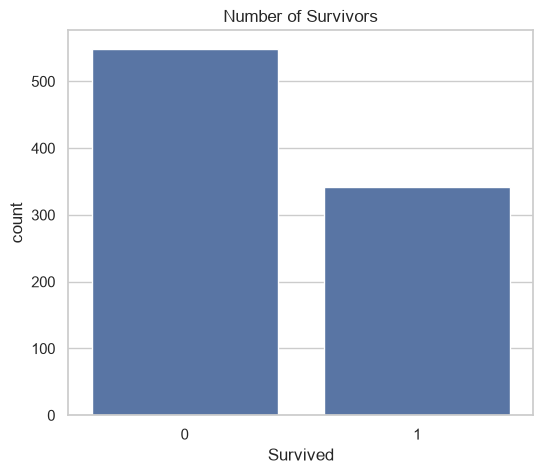

In [30]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="Survived")

plt.title("Number of Survivors")

plt.show()

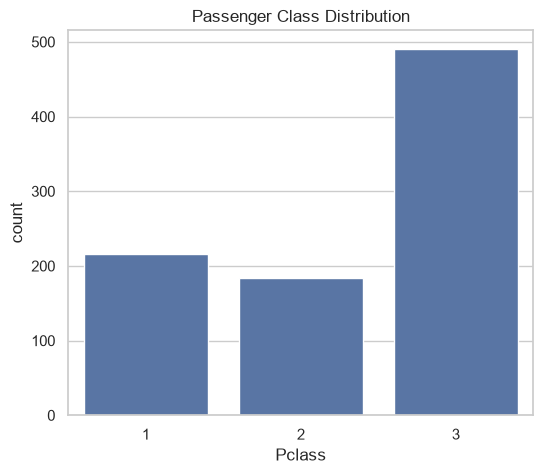

In [31]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="Pclass")

plt.title("Passenger Class Distribution")

plt.show()

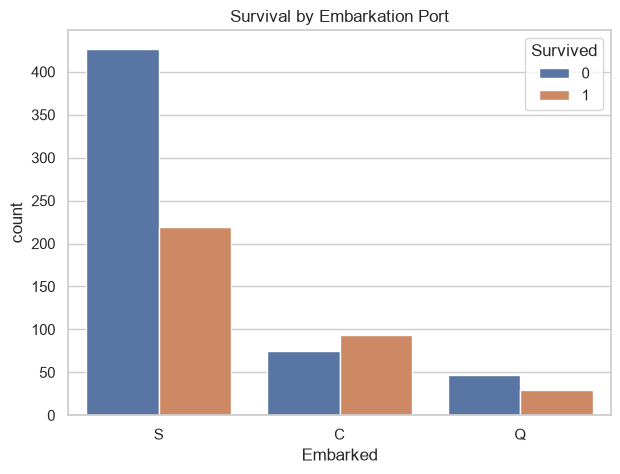

In [32]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Embarked",
              hue="Survived")

plt.title("Survival by Embarkation Port")

plt.show()

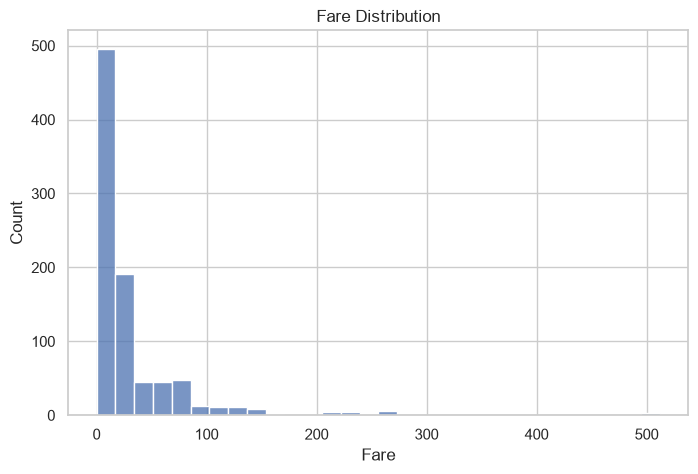

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"],
             bins=30)

plt.title("Fare Distribution")

plt.show()

In [35]:
numeric_df = df.select_dtypes(include=np.number)

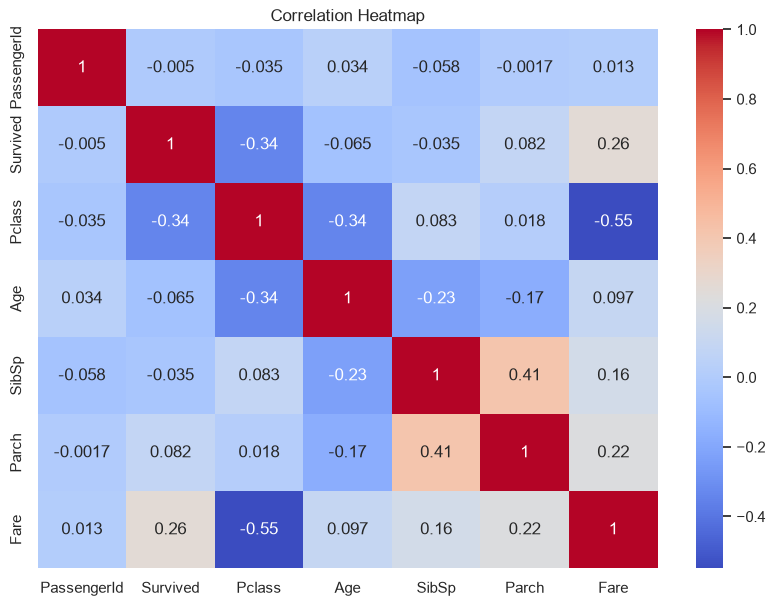

In [36]:
plt.figure(figsize=(10,7))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [37]:
print("Average Survival by Gender")
print(df.groupby("Sex")["Survived"].mean())

Average Survival by Gender
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [38]:
print("Average Survival by Passenger Class")
print(df.groupby("Pclass")["Survived"].mean())

Average Survival by Passenger Class
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [39]:
print("Average Survival by Age Group")
print(df.groupby("Age_Group")["Survived"].mean())

Average Survival by Age Group
Age_Group
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


In [40]:
df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
